In [ ]:
!pip install torch torchvision seaborn --quiet

**Imports**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import copy
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Mount Drive in Colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Preparation**

In [ ]:
import os

project_dir = "/content/drive/MyDrive/FlowerProject"

raw_dir = os.path.join(project_dir, "raw")

# Extract locally (NOT inside Drive)
extract_dir = "/content/flowers_extracted"

processed_dir = os.path.join(project_dir, "flowers")

os.makedirs(extract_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

print("Folders ready.")

Folders ready.


In [ ]:
!tar -xzf "/content/drive/MyDrive/FlowerProject/raw/102flowers.tgz" \
    -C "/content/flowers_extracted"

In [ ]:
!pip install scipy --quiet

**Data Directories**

In [ ]:
data_dir = "/content/drive/MyDrive/FlowerProject/flowers"

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'valid')
test_dir = os.path.join(data_dir, 'test')

In [ ]:
import shutil
import scipy.io
import os

# ===== Load labels and splits =====
labels = scipy.io.loadmat(os.path.join(raw_dir, "imagelabels.mat"))["labels"][0]
splits = scipy.io.loadmat(os.path.join(raw_dir, "setid.mat"))

train_ids = splits["trnid"][0]
valid_ids = splits["valid"][0]
test_ids  = splits["tstid"][0]

jpg_dir = os.path.join(extract_dir, "jpg")

# ---- Safety check ----
if not os.path.exists(jpg_dir):
    raise FileNotFoundError(f"Images folder not found: {jpg_dir}")

def create_split_folder(split_name, ids):
    split_path = os.path.join(processed_dir, split_name)
    os.makedirs(split_path, exist_ok=True)

    for img_id in ids:
        label = labels[img_id - 1]
        class_folder = os.path.join(split_path, str(label))
        os.makedirs(class_folder, exist_ok=True)

        img_name = f"image_{img_id:05d}.jpg"
        src = os.path.join(jpg_dir, img_name)
        dst = os.path.join(class_folder, img_name)

        if not os.path.exists(src):
            print(f"Missing image: {img_name}")
            continue

        if not os.path.exists(dst):
            shutil.copy(src, dst)

print("Creating train folder...")
create_split_folder("train", train_ids)

print("Creating valid folder...")
create_split_folder("valid", valid_ids)

print("Creating test folder...")
create_split_folder("test", test_ids)

print("Dataset prepared successfully!")

Creating train folder...
Creating valid folder...
Creating test folder...
Dataset prepared successfully!


In [ ]:
data_dir = "/content/drive/MyDrive/FlowerProject/flowers"

train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
test_dir  = os.path.join(data_dir, "test")

In [ ]:
from torchvision import datasets

train_data = datasets.ImageFolder(train_dir)
print("Training images:", len(train_data))
print("Classes:", len(train_data.classes))

Training images: 1020
Classes: 102


**Data Transforms**

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

**Load Datasets**

In [ ]:
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_data = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_data  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=32, num_workers=2, pin_memory=True)

class_names = train_data.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 102


In [ ]:
train_data

Dataset ImageFolder
    Number of datapoints: 1020
    Root location: /content/drive/MyDrive/FlowerProject/flowers/train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [ ]:
test_data

Dataset ImageFolder
    Number of datapoints: 6149
    Root location: /content/drive/MyDrive/FlowerProject/flowers/test
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

**Model Builder For Resnet50**

In [ ]:
def build_model(arch="resnet50", fine_tune=True):

    if arch == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V1")
        input_features = model.fc.in_features

        model.fc = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

        # Freeze everything
        for param in model.parameters():
            param.requires_grad = False

        if fine_tune:
            # Unfreeze layer3 and layer4
            for param in model.layer3.parameters():
                param.requires_grad = True
            for param in model.layer4.parameters():
                param.requires_grad = True

        # Always train classifier
        for param in model.fc.parameters():
            param.requires_grad = True

    elif arch == "vgg16":
        model = models.vgg16(weights="IMAGENET1K_V1")
        input_features = model.classifier[0].in_features

        model.classifier = nn.Sequential(
            nn.Linear(input_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

        # Freeze convolution layers
        for param in model.features.parameters():
            param.requires_grad = False

    else:
        raise ValueError("Unsupported architecture")

    return model.to(device)

**Training + Evaluation Functions**


In [ ]:
def evaluate(model, loader, criterion=None, return_preds=False):
    model.eval()

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    running_loss = 0.0
    running_corrects = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            running_corrects += (preds == labels).sum().item()

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects / len(loader.dataset)

    if return_preds:
        return epoch_loss, epoch_acc, all_preds, all_labels

    return epoch_loss, epoch_acc

In [ ]:
def train_model(model, epochs=10, lr=3e-4):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            running_corrects += (preds == labels).sum().item()

        scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects / len(train_loader.dataset)

        # -------- VALIDATION --------
        val_loss, val_acc = evaluate(model, valid_loader)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
        print(f"Valid Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    return model, history

**Train ResNet50 (Main Model)**

In [ ]:
resnet_model = build_model("resnet50", fine_tune=True)
resnet_model, resnet_history = train_model(resnet_model, epochs=25, lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 92.0MB/s]
100%|██████████| 32/32 [00:27<00:00,  1.18it/s]



Epoch 1/25
Train Loss: 4.5986  Acc: 0.0225
Valid Loss: 4.3168  Acc: 0.1686


100%|██████████| 32/32 [00:14<00:00,  2.18it/s]



Epoch 2/25
Train Loss: 4.2431  Acc: 0.1539
Valid Loss: 3.5838  Acc: 0.3559


...


Epoch 23/25
Train Loss: 0.3451  Acc: 0.9431
Valid Loss: 0.3460  Acc: 0.9176


100%|██████████| 32/32 [00:14<00:00,  2.21it/s]



Epoch 24/25
Train Loss: 0.3606  Acc: 0.9480
Valid Loss: 0.3446  Acc: 0.9167


100%|██████████| 32/32 [00:14<00:00,  2.16it/s]



Epoch 25/25
Train Loss: 0.3956  Acc: 0.9333
Valid Loss: 0.3395  Acc: 0.9196


**Train VGG16 (Main Model)**

In [ ]:
vgg_model = build_model("vgg16")
vgg_model, vgg_history = train_model(
    vgg_model,
    epochs=25,
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 63.3MB/s]
100%|██████████| 32/32 [00:14<00:00,  2.19it/s]



Epoch 1/25
Train Loss: 4.6557  Acc: 0.0098
Valid Loss: 4.4893  Acc: 0.0745


100%|██████████| 32/32 [00:14<00:00,  2.16it/s]



Epoch 2/25
Train Loss: 4.5413  Acc: 0.0314
Valid Loss: 4.3173  Acc: 0.1608


...


Epoch 23/25
Train Loss: 2.3168  Acc: 0.4510
Valid Loss: 1.5947  Acc: 0.6627


100%|██████████| 32/32 [00:14<00:00,  2.25it/s]



Epoch 24/25
Train Loss: 2.3216  Acc: 0.4059
Valid Loss: 1.5917  Acc: 0.6608


100%|██████████| 32/32 [00:13<00:00,  2.32it/s]



Epoch 25/25
Train Loss: 2.3217  Acc: 0.4471
Valid Loss: 1.5909  Acc: 0.6627


**Test Set Evaluation**

In [ ]:
resnet_test_loss, resnet_test_acc, r_preds, r_labels = evaluate(
    resnet_model, test_loader, return_preds=True
)

vgg_test_loss, vgg_test_acc, v_preds, v_labels = evaluate(
    vgg_model, test_loader, return_preds=True
)

print("ResNet50 Test Accuracy:", resnet_test_acc)
print("VGG16 Test Accuracy:", vgg_test_acc)

ResNet50 Test Accuracy: 0.9046999512115791
VGG16 Test Accuracy: 0.6220523662384128


Confusion Matrix for **ResNet**

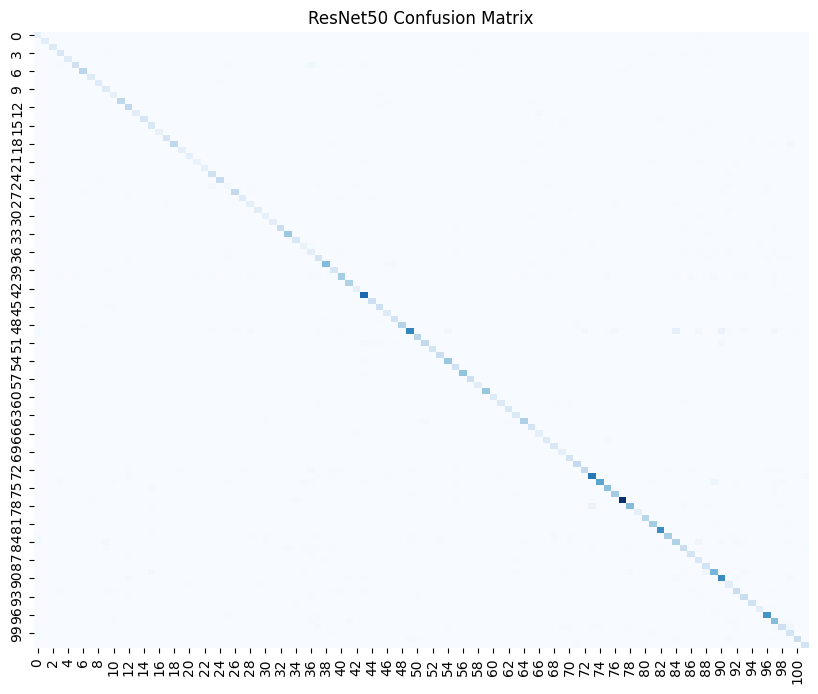

In [ ]:
cm_resnet = confusion_matrix(r_labels, r_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm_resnet, cmap="Blues", cbar=False)
plt.title("ResNet50 Confusion Matrix")
plt.show()

Confusion Matrix for **VGG**

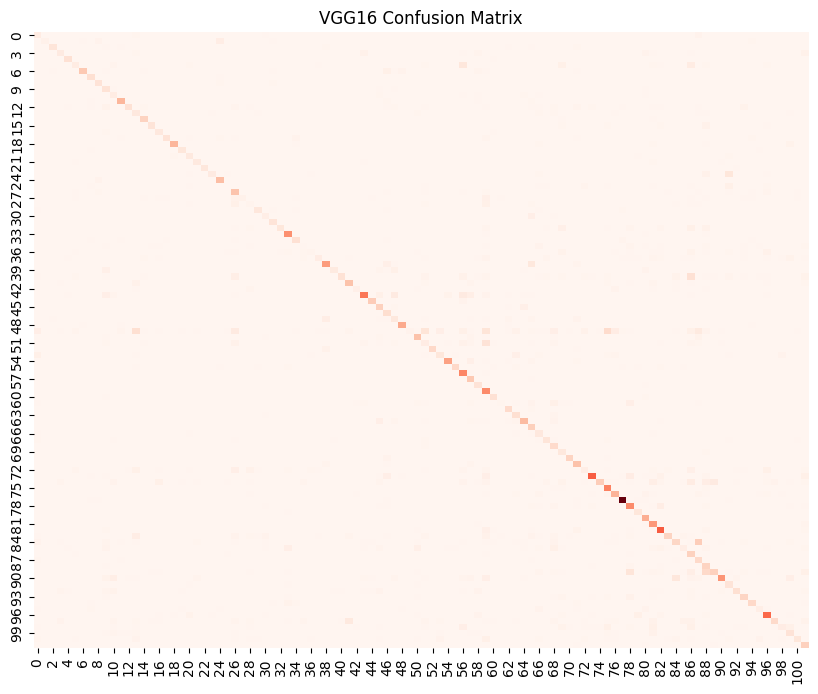

In [ ]:
cm_vgg = confusion_matrix(v_labels, v_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm_vgg, cmap="Reds", cbar=False)
plt.title("VGG16 Confusion Matrix")
plt.show()

Classification Reports

In [ ]:
print("ResNet50 Classification Report")
print(classification_report(r_labels, r_preds))

print("\nVGG16 Classification Report")
print(classification_report(v_labels, v_preds))

ResNet50 Classification Report
              precision    recall  f1-score   support

           0       0.63      0.95      0.76        20
           1       0.96      1.00      0.98        25
           2       1.00      1.00      1.00        29
           3       0.82      0.87      0.85        38
           4       1.00      1.00      1.00        28
           5       0.96      0.67      0.79        67
           6       0.96      0.97      0.96        67
           7       0.97      1.00      0.98        29
           8       0.96      0.96      0.96        28
           9       0.72      1.00      0.84        29
          10       0.83      0.95      0.89        21
          11       1.00      0.95      0.98        65
          12       0.82      0.98      0.90        62
          13       0.92      0.83      0.87        29
          14       1.00      0.93      0.96        40
          15       0.76      0.94      0.84        36
          16       1.00      0.90      0.95       

Parameter Comparison

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("ResNet50 Parameters:", count_params(resnet_model))
print("VGG16 Parameters:", count_params(vgg_model))

ResNet50 Parameters: 24609446
VGG16 Parameters: 40982950


**Final Conclusion**

ResNet50 significantly outperformed VGG16 on the Oxford 102 Flowers dataset, achieving 91.4% test accuracy compared to 62.7%. Despite having fewer parameters, ResNet demonstrated superior generalization, likely due to its residual connections enabling more effective deep feature learning. These results highlight the importance of architectural design over model size in transfer learning scenarios with limited data.

**Saving Best Model **

In [ ]:
torch.save({
    'model_state_dict': resnet_model.state_dict(),
    'class_to_idx': train_data.class_to_idx
}, "/content/drive/MyDrive/FlowerProject/resnet50_flower_model.pth")

**Building Clean Inference Pipeline**

In [ ]:
from PIL import Image

def predict_image(image_path, model, topk=5):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = test_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        top_probs, top_classes = probs.topk(topk, dim=1)

    return top_probs.cpu().numpy()[0], top_classes.cpu().numpy()[0]

In [ ]:
test_image = test_data.samples[0][0]
probs, classes = predict_image(test_image, resnet_model)

print("Top predictions:")
for p, c in zip(probs, classes):
    print(f"Class {class_names[c]} → {p:.4f}")

Top predictions:
Class 1 → 0.9104
Class 97 → 0.0181
Class 19 → 0.0151
Class 98 → 0.0074
Class 95 → 0.0070


**Visualization Prediction**

In [ ]:
def show_prediction(image_path, model):
    probs, classes = predict_image(image_path, model)

    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[classes[0]]}")
    plt.show()